# Chicago Crime Analysis

<div style="width:100%; height:400px; overflow:hidden;">
    <img src="chicago.jpg" style="width:100%; margin-top:-100px;">
</div>

In [1]:
# pip install pandas, numpy, matplotlib, seaborn, sodapy, geopandas, shape

In [2]:
# Using for API scraping
import os 
import csv
from sodapy import Socrata # scraping tool, similar to requests
from dotenv import load_dotenv

# Must-have data analysis modules
import pandas as pd 
import numpy as np

# Visualization
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

# Geographical Analysis
import geopandas as gpd
from shapely.geometry import shape 

## Loading Data

<u>Official example from sodapy</u>

import pandas as pd<br>
from sodapy import Socrata<br>

client = Socrata("data.cityofchicago.org", token)<br>

results = client.get("ijzp-q8t2", limit=10000)

In [3]:
# Read the env file first to extract API key
load_dotenv()

# Setting up client for API scraping
APP_TOKEN = os.environ.get("TOKEN")
client = Socrata("data.cityofchicago.org", APP_TOKEN, timeout=60)

# client.get parameters
DATASET_ID = "ijzp-q8t2" # Place dataset id here
START_DATE = "2021-01-01T00:00:00.000" # Place the date filter (start date) here
CHUNK_SIZE = 40000 
csv_filename = "crimes_2021_present.csv"
checkpoint_filename = "checkpoint.txt"


# Scenario 1: A previous run crashed/stopped mid-way. Resume using the checkpoint.
if os.path.exists(checkpoint_filename):
    with open(checkpoint_filename, "r") as f:
        lines = f.read().splitlines()
        last_date = lines[0]
        last_id = lines[1]
    print(f"Resuming crashed run from Last Date: {last_date} | Last ID: {last_id}")
    is_first_chunk = not os.path.exists(csv_filename)

# Scenario 2: Previous run finished, and CSV exists. Perform an incremental daily catch-up.
elif os.path.exists(csv_filename) and os.path.getsize(csv_filename) > 0:
    print(f"Found existing CSV. Finding your last recorded data position...")
    
    # High-performance backward byte-search to instantly read only the last row
    with open(csv_filename, "rb") as f:
        try:
            f.seek(-2, os.SEEK_END)
            while f.read(1) != b"\n":
                f.seek(-2, os.SEEK_CUR)
        except OSError:
            f.seek(0)  # Handles cases where the file only has one or two rows
        last_line_raw = f.readline().decode().strip()
    
    # Match the last line values back to their correct column positions
    headers = pd.read_csv(csv_filename, nrows=0).columns.tolist()
    last_line = list(csv.reader([last_line_raw]))[0]
    last_date = last_line[headers.index("date")]
    last_id = last_line[headers.index("id")]
    
    is_first_chunk = False
    print(f"Catching up on new crimes recorded since: {last_date} (ID: {last_id})")

# State 3: First time attempt
else:
    last_date = START_DATE
    last_id = None
    print(f"No files found. Starting a fresh historical extraction from {last_date}...")
    is_first_chunk = True

# --- EXTRACTION LOOP ---
page_count = 1

while True:
    print(f"Fetching page {page_count}...")
    
    # Optimized SoQL syntax for compound keyset pagination
    if last_id:
        where_clause = f"date >= '{last_date}' AND (date > '{last_date}' OR id > '{last_id}')"
    else:
        where_clause = f"date >= '{last_date}'"
        
    try:
        # Here is where it starts the scraping
        chunk = client.get(
            DATASET_ID,
            where=where_clause,
            order="date ASC, id ASC", 
            limit=CHUNK_SIZE
        )
        
        # If the chunk is empty, we are completely caught up to current time
        if not chunk:
            print("Finished! Reached the end of the dataset. Everything is up to date.")
            if os.path.exists(checkpoint_filename):
                os.remove(checkpoint_filename)
            break
            
        chunk_df = pd.DataFrame.from_records(chunk)
        
        # Save chunk to CSV
        if is_first_chunk:
            # Save the exact initial column layout 
            csv_headers = chunk_df.columns.tolist()
            chunk_df.to_csv(csv_filename, index=False)
            is_first_chunk = False
        else:
            # Read the master column list from the existing CSV headers
            csv_headers = pd.read_csv(csv_filename, nrows=0).columns.tolist()
            
            # Reindex forces chunk_df to match the original CSV columns perfectly.
            # Any missing columns in this chunk will gracefully fill with NaN instead of shifting everything!
            chunk_df = chunk_df.reindex(columns=csv_headers)
            
            # Now it is completely safe to append
            chunk_df.to_csv(csv_filename, mode='a', header=False, index=False)
            
        # Track the last record's date and ID for the next cursor position
        chunk_df = chunk_df.sort_values(by=["date", "id"], ascending=[True, True])
        last_record = chunk_df.iloc[-1]
        
        last_date = last_record["date"]
        last_id = last_record["id"]
        
        # Save state vectors to checkpoint file in case of an incoming network drop
        with open(checkpoint_filename, "w") as f:
            f.write(f"{last_date}\n{last_id}")
            
        print(f"Saved chunk. Current position: {last_date}")
        page_count += 1
        
    except Exception as e:
        print(f"Error encountered: {e}")
        print(f"Progress saved locally. Re-run this code block whenever you are ready to resume safely.")
        break

Found existing CSV. Finding your last recorded data position...
Catching up on new crimes recorded since: 2026-06-22T00:00:00.000 (ID: 14242509)
Fetching page 1...
Finished! Reached the end of the dataset. Everything is up to date.


In [4]:
df = pd.read_csv("crimes_2021_present.csv")

df.head(2)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,12258562,JE100027,2021-01-01T00:00:00.000,054XX W QUINCY ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,29.0,25.0,08B,1140261.0,1898470.0,2021,2021-01-16T15:39:23.000,41.877496,-87.760467,"{'latitude': '41.877495524', 'longitude': '-87..."
1,12258747,JE100294,2021-01-01T00:00:00.000,123XX S HALSTED ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,...,34.0,53.0,08B,1173227.0,1823129.0,2021,2021-01-16T15:39:23.000,41.670084,-87.641650,"{'latitude': '41.670083502', 'longitude': '-87..."


In [5]:
print(f'The quantitative analysis presented in this study relies on open-source public safety data with a strict cutoff date of {df.tail(1)[['date']]}')

The quantitative analysis presented in this study relies on open-source public safety data with a strict cutoff date of                             date
1315089  2026-06-22T00:00:00.000


# The quantitative analysis presented in this study relies on open-source public safety data with a strict cutoff date of 20 June 2026

In [6]:
# Population dataset for calculating crime rate
# Source: https://experience.arcgis.com/experience/f16ab5d8de1d484aa8af7bf67fc4a920/page/CCA-Explorer (accessed data 18/6/2026)
# Method: I manually input each community_area name and its population figure into a csv file.

population_by_community_area = pd.read_csv("population_by_community_area_2025.csv")

population_by_community_area.head(2)

,Community Area,Total Population
0,ALBANY PARK,"46,620"
1,ARCHER HEIGHTS,"14,021"


In [7]:
# Map Dataset for geometric analysis
# Source: https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6

result = client.get("igwz-8jzy", limit=2000)
chicago_map = pd.DataFrame(result)

# Transfer the dictionary into Shapely MultiPolygon
shapes = chicago_map['the_geom'].apply(shape) 

# Set the geometry as column geometry
chicago_map = gpd.GeoDataFrame(chicago_map, geometry=shapes)

chicago_map["area_num_1"] = chicago_map["area_num_1"].astype(int)

chicago_map.head(2)

,the_geom,area_numbe,community,area_num_1,shape_area,shape_len,geometry
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1,ROGERS PARK,1,51259902.4506,34052.3975757,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2,WEST RIDGE,2,98429094.8621,43020.6894583,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."


In [8]:
# IUCR code for crime type labelling
# Source: https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/data_preview

result = client.get("c7ck-438e", limit=2000)

iucr = pd.DataFrame(result)

iucr = iucr.rename(columns={"index_code": "cpd_main_category"}).replace({"I": "INDEX", "N": "NON-INDEX"})

iucr = iucr[["iucr", "cpd_main_category"]]

iucr.head(2)

,iucr,cpd_main_category
0,0110,INDEX
1,0130,INDEX


## Data Cleansing & Processing

In [9]:
rows, columns = df.shape

print(f"This dataset contains {rows} rows and {columns} columns")

This dataset contains 1315090 rows and 22 columns


In [10]:
# Check for missing value

print("Columns that contain missing values:")
for col in df.columns:
    pct_missing = (len(df.loc[df[col].isna()]) / len(df))*100
    if pct_missing > 0:
        print(f"{col} - {pct_missing:.2f}% ({len(df.loc[df[col].isna()])})")


print("\nFinal results:") 
print(f"{(1 - (len(df.dropna()) / len(df)))*100:.2f}% ({len(df) - len(df.dropna())}) of rows containing NA values will be removed from the total dataset")

Columns that contain missing values:
location_description - 0.51% (6702)
ward - 0.00% (25)
community_area - 0.01% (114)
x_coordinate - 1.33% (17470)
y_coordinate - 1.33% (17470)
latitude - 1.33% (17470)
longitude - 1.33% (17470)
location - 1.33% (17470)

Final results:
1.76% (23080) of rows containing NA values will be removed from the total dataset


In [11]:
# Remove missing values

df = df.dropna()

In [12]:
# Check for duplicate values

print(f"This dataset contains {df.duplicated().sum()} of duplicates.")

This dataset contains 0 of duplicates.


In [13]:
# Data processing for Time-Series Purpose

df["date"] = pd.to_datetime(df["date"], cache=True) # Cache = True is needed to reduce processing time

df['Year'] = df["date"].dt.year # Although the original dataset has the year column, to prevent from api bugs, new year column is need to ensure the results.

df["period"] = pd.to_datetime((df["date"].dt.year * 100 + df["date"].dt.month).astype(str), format='%Y%m')

df["hour"] = df["date"].dt.hour

df["weekday"] = df["date"].dt.day_name()

In [14]:
# Data processing for Geographic Purpose

# To get the name of community name
df = pd.merge(df, chicago_map[["area_num_1", "community"]], how="inner", left_on="community_area", right_on="area_num_1").drop(columns="area_num_1") 

# Update datatype for matching chicago_map 'area_num_1' for later on visualization labelling
df["community_area"] = df["community_area"].astype(int) 

df.head(2)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,year,updated_on,latitude,longitude,location,Year,period,hour,weekday,community
0,12258562,JE100027,2021-01-01,054XX W QUINCY ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,2021,2021-01-16T15:39:23.000,41.877496,-87.760467,"{'latitude': '41.877495524', 'longitude': '-87...",2021,2021-01-01,0,Friday,AUSTIN
1,12258747,JE100294,2021-01-01,123XX S HALSTED ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,...,2021,2021-01-16T15:39:23.000,41.670084,-87.641650,"{'latitude': '41.670083502', 'longitude': '-87...",2021,2021-01-01,0,Friday,WEST PULLMAN


In [15]:
# Data processing for Categorization Purpose
# Using IUCR code to lookup main category label

df = df.merge(iucr, how="left", on="iucr")

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,latitude,longitude,location,Year,period,hour,weekday,community,cpd_main_category
0,12258562,JE100027,2021-01-01,054XX W QUINCY ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,2021-01-16T15:39:23.000,41.877496,-87.760467,"{'latitude': '41.877495524', 'longitude': '-87...",2021,2021-01-01,0,Friday,AUSTIN,NON-INDEX
1,12258747,JE100294,2021-01-01,123XX S HALSTED ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,...,2021-01-16T15:39:23.000,41.670084,-87.641650,"{'latitude': '41.670083502', 'longitude': '-87...",2021,2021-01-01,0,Friday,WEST PULLMAN,NON-INDEX
2,12258761,JE100304,2021-01-01,099XX S PEORIA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,DRIVEWAY - RESIDENTIAL,False,False,...,2021-01-16T15:39:23.000,41.713307,-87.645431,"{'latitude': '41.713307488', 'longitude': '-87...",2021,2021-01-01,0,Friday,WASHINGTON HEIGHTS,NON-INDEX
3,12258861,JE100369,2021-01-01,016XX N CICERO AVE,051A,ASSAULT,AGGRAVATED - HANDGUN,ALLEY,False,False,...,2021-01-16T15:39:23.000,41.910910,-87.745899,"{'latitude': '41.910909931', 'longitude': '-87...",2021,2021-01-01,0,Friday,AUSTIN,INDEX
4,12258870,JE100519,2021-01-01,048XX N WINTHROP AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE - GARAGE,False,False,...,2021-01-16T15:39:23.000,41.970383,-87.657657,"{'latitude': '41.970382978', 'longitude': '-87...",2021,2021-01-01,0,Friday,UPTOWN,NON-INDEX


In [16]:
# Verify missing values after merging

main_cat_missing = df["cpd_main_category"].isna().sum()

print(f"There is {main_cat_missing} missing values for new column: cpd_main_category") 

There is 0 missing values for new column: cpd_main_category


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1292010 entries, 0 to 1292009
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   id                    1292010 non-null  int64         
 1   case_number           1292010 non-null  str           
 2   date                  1292010 non-null  datetime64[us]
 3   block                 1292010 non-null  str           
 4   iucr                  1292010 non-null  str           
 5   primary_type          1292010 non-null  str           
 6   description           1292010 non-null  str           
 7   location_description  1292010 non-null  str           
 8   arrest                1292010 non-null  bool          
 9   domestic              1292010 non-null  bool          
 10  beat                  1292010 non-null  int64         
 11  district              1292010 non-null  int64         
 12  ward                  1292010 non-null  float64      

In [18]:
# Main Dataset after data processing and cleaning

df.head(2)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,latitude,longitude,location,Year,period,hour,weekday,community,cpd_main_category
0,12258562,JE100027,2021-01-01,054XX W QUINCY ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,2021-01-16T15:39:23.000,41.877496,-87.760467,"{'latitude': '41.877495524', 'longitude': '-87...",2021,2021-01-01,0,Friday,AUSTIN,NON-INDEX
1,12258747,JE100294,2021-01-01,123XX S HALSTED ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,...,2021-01-16T15:39:23.000,41.670084,-87.641650,"{'latitude': '41.670083502', 'longitude': '-87...",2021,2021-01-01,0,Friday,WEST PULLMAN,NON-INDEX


## Exploratory Data Analysis (EDA)

### EDA 1: Historical Crime Trends and Structure (From 2021 - 2025)

In [19]:
# Filtered data for EDA 1 (2021-2025 only)

df_2021_2025 = df.loc[df["Year"]!=2026]

#### Time-Series Analysis of Crime Volume

In [20]:
# The main data source for line chart
case_per_period = df_2021_2025.groupby("period").size().reset_index(name="total_cnt") 

# Used for Line Chart Annotation 
label_data = df_2021_2025.groupby(["Year", "period"]).size().reset_index(name="cnt")

# Creating yearly min label
year_min = label_data.groupby("Year")["cnt"].min().reset_index()

min_period = case_per_period.loc[case_per_period["total_cnt"].isin(year_min["cnt"])] # Extract month that is in yearly minimum

# Creating yearly max label
year_max = label_data.groupby("Year")["cnt"].max().reset_index()

max_period = case_per_period.loc[case_per_period["total_cnt"].isin(year_max["cnt"])] # Extract month that is in yearly maximum

In [21]:
# Setting Fig
fig = px.scatter(x=case_per_period["period"], y=case_per_period["total_cnt"], 
                 title="<u>Overall <b>Crime Incident Count</b> by Period from 2021 Jan - 2025 Dec</u>",
                 height=700, width=1200)

# Adding min labels to the graph
for index, row in min_period.iterrows():
    x_val = row["period"]
    y_val = row["total_cnt"]
    
    fig.add_annotation(
        x=x_val,
        y=y_val,
        text=f"<b>Min</b>: {x_val.month_name()[:3]} / <b>Count</b>: {y_val}",
        showarrow=True,
        arrowhead=2,
        arrowcolor="Red",
        ax=80, 
        ay=25  # Moves text box 30 pixels down so it doesn't overlap the line
    )

# Adding max labels to the graph
for index, row in max_period.iterrows():
    x_val = row["period"]
    y_val = row["total_cnt"]
    
    fig.add_annotation(
        x=x_val,
        y=y_val,
        text=f"<b>Max</b>: {x_val.month_name()[:3]} / <b>Count</b>: {y_val}",
        showarrow=True,
        arrowhead=1,
        arrowcolor="Green",
        ax=0, 
        ay=-30  # Moves text box 30 pixels down so it doesn't overlap the line
    )

fig.update_traces(mode="lines")
fig.update_xaxes(title="Date", tickmode="array", tickvals=["2021-01", "2022-01", "2023-01", "2024-01", "2025-01"], 
                 ticktext=["Jan 2021", "Jan 2022", "Jan 2023", "Jan 2024", "Jan 2025",],range=["2020-11", "2026-02"])
fig.update_yaxes(title="Crime Count", showgrid=False, range=[10000, 26000])
fig.show()

#### Crime Structure and Category Composition

In [22]:
# Summarized data for Treemap Chart

df_tree = df_2021_2025.groupby(["cpd_main_category", "primary_type"]).size().reset_index(name="crime_count")

df_tree.head(1)

,cpd_main_category,primary_type,crime_count
0,INDEX,ARSON,2273


In [ ]:
# Setting the Figure
fig = px.treemap(
    df_tree, 
    path=[px.Constant("Chicago"), "cpd_main_category", "primary_type"], 
    values="crime_count",
    title="<b>Chicago Crime Structural Composition Matrix</b><br>Thematic Hierarchy Analysis (2021-2025)",
    height=700, width=700
)

# Adjust color manually by fig.data[0]
labels = fig.data[0].labels
parents = fig.data[0].parents
ids = fig.data[0].ids  # The key to unlocking explicit paths!

# Customized color palette
color_hierarchy = {
    # Main Root Headers
    "Chicago": "#111827",
    "INDEX": "#112233",           
    "NON-INDEX": "#613111",       
    
    # Index Crime Color Map
    "THEFT": "#2A4365", 
    "MOTOR VEHICLE THEFT": "#2B6CB0", 
    "BURGLARY": "#4299E1",
    "ARSON": "#63B3ED",
    "Violent Crime_INDEX": "#243E56", 
    "ROBBERY": "#2C5282", 
    "BATTERY_INDEX": "#3182CE", 
    "ASSAULT_INDEX": "#4997D0", 
    "HOMICIDE": "#63B3ED",
    "CRIMINAL SEXUAL ASSAULT": "#90CDF4",
    "HUMAN TRAFFICKING": "#EBF8FF",
    "OFFENSE INVOLVING CHILDREN_INDEX": "#95B5F9",
    

    # Non-Index Crime Color Map
    'BATTERY': '#854F26',               
    'CRIMINAL DAMAGE': '#945D34',       
    'OTHER OFFENSE': '#A06B44',         
    'DECEPTIVE PRACTICE': '#AD7A54',    
    'ASSAULT': '#BA8965',              
    'WEAPONS VIOLATION': '#C69775',     
    'NARCOTICS': '#D1A687',            
    'CRIMINAL TRESPASS': '#DBB599',     
    'OFFENSE INVOLVING CHILDREN': '#E5C4AC',
    'PUBLIC PEACE VIOLATION': '#ECD2BE',
    'SEX OFFENSE': '#F3E1D2',
    'INTERFERENCE WITH PUBLIC OFFICER': '#F8EBE0',
    'STALKING': '#FBF3EC',
    'INTIMIDATION': '#FDF8F5', 
    'PROSTITUTION': '#FFFDFB',
    'GAMBLING': '#FFFDFB',
    'LIQUOR LAW VIOLATION': '#FFFDFB',
    'CONCEALED CARRY LICENSE VIOLATION': '#FFFDFB',
    'OBSCENITY': '#FFFDFB',
    'PUBLIC INDECENCY': '#FFFDFB',
    'KIDNAPPING': '#FFFDFB',
    'OTHER NARCOTIC VIOLATION': '#FFFDFB',
    'NON-CRIMINAL': '#FFFFFF' 
}

final_colors = []
for label, parent, current_id in zip(labels, parents, ids):
    current_id_str = str(current_id)
    
    # Check if this leaf or branch belongs to the Non-Index root path
    if "NON-INDEX" in current_id_str:
        if label in color_hierarchy:
            final_colors.append(color_hierarchy[label])
        elif parent in color_hierarchy:
            final_colors.append(color_hierarchy[parent])
        else:
            final_colors.append("#A06B44") 
            
    # If it doesn't contain NON-INDEX, it safely falls into the INDEX branch scope
    else:
        if label == "BATTERY":
            final_colors.append(color_hierarchy["BATTERY_INDEX"])
        elif label == "ASSAULT":
            final_colors.append(color_hierarchy["ASSAULT_INDEX"])
        elif label == "OFFENSE INVOLVING CHILDREN":
            final_colors.append(color_hierarchy["OFFENSE INVOLVING CHILDREN_INDEX"])
        elif label in color_hierarchy:
            final_colors.append(color_hierarchy[label])
        elif parent in color_hierarchy:
            final_colors.append(color_hierarchy[parent])
        else:
            final_colors.append("#1A365D") 

# Inject the perfectly processed color map directly back into the trace
fig.data[0].marker.colors = final_colors

# Apply text in each box in the treemap
fig.update_traces(
    texttemplate="<b>%{label}</b><br>Count: %{value}<br>%{percentRoot:.2%} of City Total",
    hovertemplate="<b>Crime Type:</b> %{label}<br><b>Incident Count:</b> %{value:,}<br>"
                  "---------------------------------------------------<br>Share of Category Container: %{percentParent:.1%}<br>" \
                  "Share of Absolute City Total: %{percentRoot:.1%}<extra></extra>",
    textfont_color="white",
    marker_line_color="white",  # Crisp clean boundary separations
    marker_line_width=1.5
)

fig.show()

#### Correlations Between Crime Categories and Total Crime Volume

In [24]:
# Overall crime vs. main_category crime (INDEX & NON-INDEX)

crime_cnt_by_group = df_2021_2025.groupby(["period", "cpd_main_category"]).size().reset_index(name="cnt") # find the summarized data we need

overall_count = crime_cnt_by_group.groupby("period")["cnt"].sum().reset_index(name="cnt") # total crime count per year

index_count = crime_cnt_by_group.loc[crime_cnt_by_group["cpd_main_category"] == "INDEX"] # index crime count per year

non_index_count = crime_cnt_by_group.loc[crime_cnt_by_group["cpd_main_category"] == "NON-INDEX"] # non-index crime count per year


# Merge dataset

corr_data = overall_count.merge(index_count, on="period").merge(non_index_count, on="period").drop(columns=["cpd_main_category_x","cpd_main_category_y"])

corr_data = corr_data.rename(columns={"cnt_x": "total_cnt", "cnt_y": "index_cnt", "cnt": "non_index_cnt"})


# Perform Relative Normalization in pct_change columns

corr_data['total_change'] = round((corr_data['total_cnt'].pct_change(1) * 100), 2)

corr_data['index_change'] = round((corr_data['index_cnt'].pct_change(1) * 100), 2)

corr_data['non_index_change'] = round((corr_data['non_index_cnt'].pct_change(1) * 100), 2)

In [25]:
# Remove the first month record, as it don't have the percentage change

corr_data.dropna(inplace=True)

corr_data.head(2)

,period,total_cnt,index_cnt,non_index_cnt,total_change,index_change,non_index_change
1,2021-02-01,12702,4533,8169,-18.98,-20.83,-17.92
2,2021-03-01,15580,5693,9887,22.66,25.59,21.03


In [26]:
# Necessary key metric labels for the regression line

corr_index_non_index = corr_data['index_change'].corr(corr_data['non_index_change']) # Pearson correlation coefficient
index_std = corr_data['index_change'].std() # Index Crime Standard Deviation
non_index_std = corr_data['non_index_change'].std() # Non-Index Crime Standard Deviation

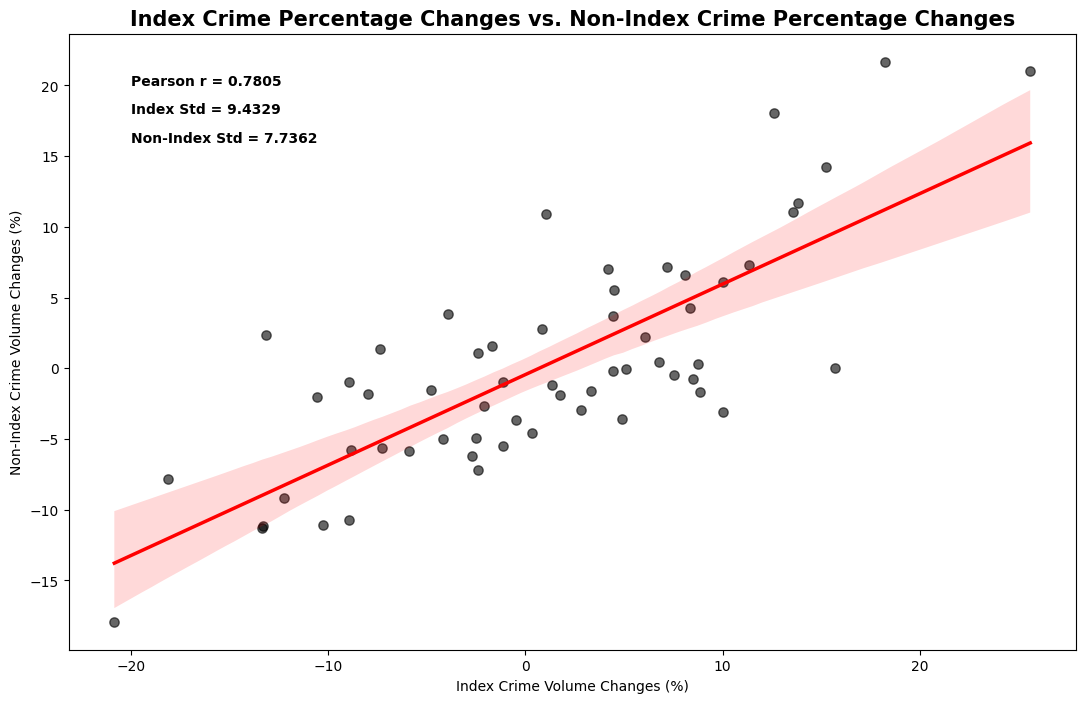

In [27]:
# Visualization

plt.figure(figsize=(13,8))
sns.regplot(data=corr_data, x="index_change", y="non_index_change", scatter_kws={"color":"Black", "alpha":0.6, "s":45},
            line_kws={"color": "red", "linewidth": 2.5})
plt.title("Index Crime Percentage Changes vs. Non-Index Crime Percentage Changes", weight="bold", size=15)
plt.xlabel("Index Crime Volume Changes (%)")
plt.ylabel("Non-Index Crime Volume Changes (%)")
plt.text(x=-20, y=20, s=f"Pearson r = {corr_index_non_index:.4f}", weight="bold")
plt.text(x=-20, y=18, s=f"Index Std = {index_std:.4f}", weight="bold")
plt.text(x=-20, y=16, s=f"Non-Index Std = {non_index_std:.4f}", weight="bold")
plt.show()


### EDA 2: Visitor Safety Analysis in Tourism Related Areas: 2026 YTD

#### Spatial Distribution and Proxy Risk by Community Area

In [28]:
# Filtered data for EDA 2 (2026 YTD only)

df_2026 = df.loc[df["Year"] == 2026]

In [29]:
# Filtering Crimes and Locations that Tourist may face or visit
# All extract from ['Primary Type', 'Location Description'] Columns

tourist_crimes = ["ROBBERY", "ASSAULT", "BATTERY", "THEFT", "CRIMINAL DAMAGE"]

tourist_location = ["AIRCRAFT", "AIRPORT TERMINAL UPPER LEVEL - SECURE AREA", "AIRPORT TERMINAL UPPER LEVEL - NON-SECURE AREA",
                   "AIRPORT TERMINAL LOWER LEVEL - SECURE AREA", "AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA",
                   "AIRPORT EXTERIOR - NON-SECURE AREA", "AIRPORT PARKING LOT", "HOTEL / MOTEL", "HOTEL", "MOTEL",
                   "TAXICAB", "VEHICLE - OTHER RIDE SHARE SERVICE (LYFT, UBER, ETC.)", "RESTAURANT", "BAR OR TAVERN", 
                   "TAVERN / LIQUOR STORE", "TAVERN", "SPORTS ARENA / STADIUM", "MOVIE HOUSE / THEATER", "CASINO/GAMBLING ESTABLISHMENT", 
                   "BANQUET HALL", "CLUB", "DEPARTMENT STORE", "SMALL RETAIL STORE", "RETAIL STORE", "GROCERY FOOD STORE", "CONVENIENCE STORE", 
                   "DRUG STORE", "PARK PROPERTY", "LAKEFRONT / WATERFRONT / RIVERBANK", "BEACH", "LIBRARY"]


In [30]:
df.columns

Index(['id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate',
       'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude',
       'location', 'Year', 'period', 'hour', 'weekday', 'community',
       'cpd_main_category'],
      dtype='str')

In [31]:
# Highlight crimes that tourist will care the most, extract those data and perform exploratory data analysis

tourist_df = df_2026.loc[(df_2026["primary_type"].isin(tourist_crimes)) & df_2026["location_description"].isin(tourist_location)]

# 2. Get the crime counts for each Community Area
area_counts = tourist_df.groupby(["community", "community_area"]).size().reset_index(name = "Street_Crime_Count")

area_counts.head(1)

,community,community_area,Street_Crime_Count
0,ALBANY PARK,14,106


In [32]:
population_by_community_area.head(1)

,Community Area,Total Population
0,ALBANY PARK,"46,620"


In [33]:
# Used for Community Area Visualization
crime_rate_2026 = pd.merge(area_counts, population_by_community_area, left_on="community", right_on="Community Area").drop(columns="Community Area")

crime_rate_2026 = crime_rate_2026.rename(columns={"community_area": "community_code"})

crime_rate_2026["Total Population"] = crime_rate_2026["Total Population"].str.replace({",":""}).astype(int)

crime_rate_2026["crime_rate_per_10k"] = (crime_rate_2026["Street_Crime_Count"] / crime_rate_2026["Total Population"]) * 10000

crime_rate_2026.head(1)

,community,community_code,Street_Crime_Count,Total Population,crime_rate_per_10k
0,ALBANY PARK,14,106,46620,22.737023


In [34]:
# Used geometric dataset to setup Map Plot

merged_map = chicago_map.merge(crime_rate_2026, on="community")

merged_map.head(2)

,the_geom,area_numbe,community,area_num_1,shape_area,shape_len,geometry,community_code,Street_Crime_Count,Total Population,crime_rate_per_10k
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1,ROGERS PARK,1,51259902.4506,34052.3975757,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ...",1,168,54388,30.889167
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2,WEST RIDGE,2,98429094.8621,43020.6894583,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ...",2,120,78227,15.339972


In [35]:
# 1. Isolate the exact Top 10 DataFrames and create a list of their IDs
crime_rate_2026_top_10 = crime_rate_2026.sort_values(by="crime_rate_per_10k", ascending=False).head(10)

top_10_area_numbers = crime_rate_2026_top_10["community_code"].tolist() 

In [36]:
crime_rate_2026_top_10.head()

,community,community_code,Street_Crime_Count,Total Population,crime_rate_per_10k
41,LOOP,32,1102,42181,261.255067
56,OHARE,76,215,14004,153.527564
47,NEAR NORTH SIDE,8,1474,104712,140.767056
49,NEAR WEST SIDE,28,725,66084,109.708855
58,PULLMAN,50,66,6741,97.908322


In [37]:
Community_Area_Name_Map = dict(zip(df_2026["community_area"].astype(int), df_2026["community"]))

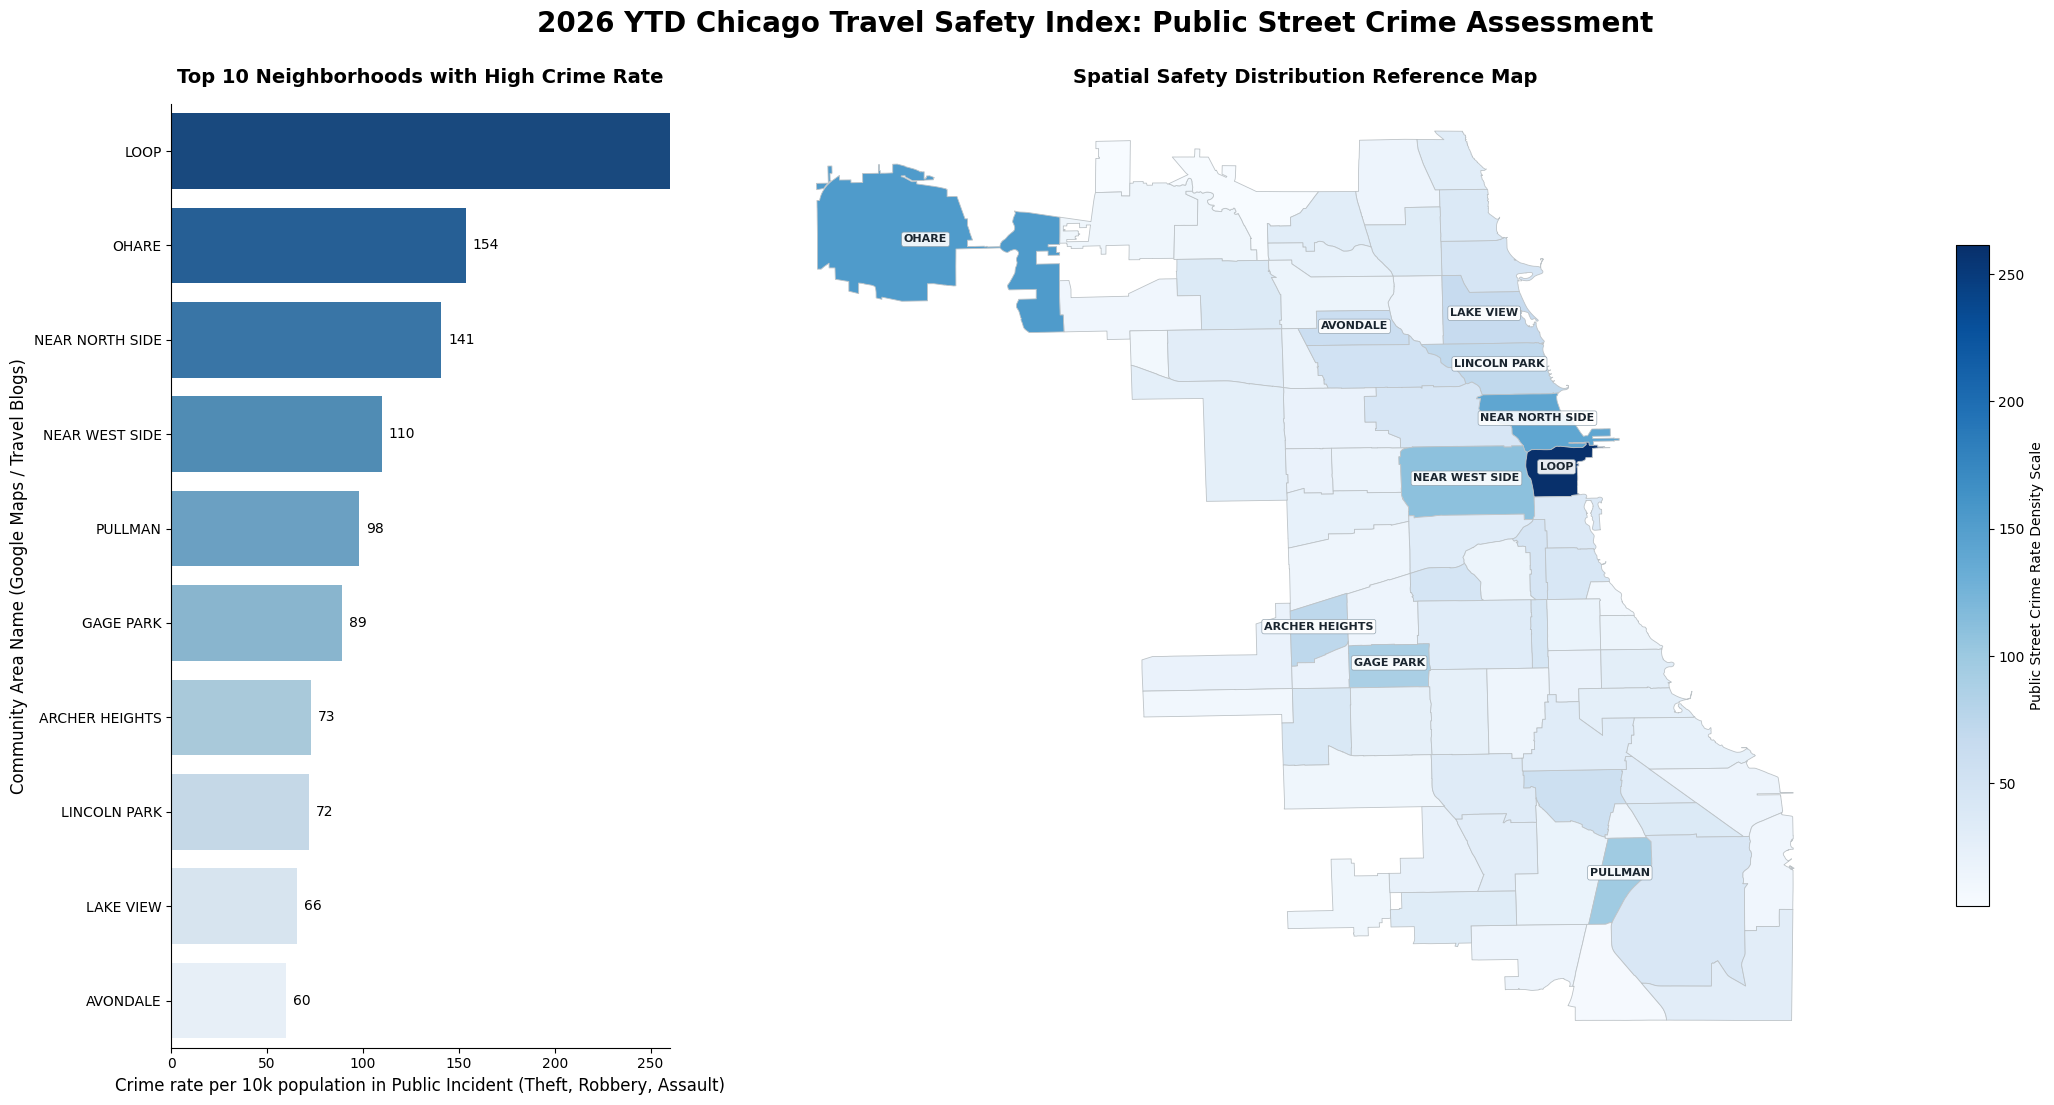

In [38]:
# Setting for the fig:
fig, ax = plt.subplots(1, 2, figsize=(22, 11), gridspec_kw={"width_ratios": [1, 3]})

# Column 0 Plot: Top 10 Bar Chart
sns.barplot(
    data=crime_rate_2026_top_10,
    x="crime_rate_per_10k",
    y="community",
    palette="Blues_r", 
    hue="community",
    legend=False,
    ax=ax[0]
)

# Adding bar labels 
for container in ax[0].containers:
    ax[0].bar_label(
        container, 
        fmt="%.0f",          
        padding=5,           
        fontsize=10          
    )

# Other Setting
ax[0].set_title("Top 10 Neighborhoods with High Crime Rate", fontsize=14, weight="bold", pad=15)
ax[0].set_xlabel("Crime rate per 10k population in Public Incident (Theft, Robbery, Assault)", fontsize=12)
ax[0].set_ylabel("Community Area Name (Google Maps / Travel Blogs)", fontsize=12)
ax[0].set_xlim([0, 260])
sns.despine(ax=ax[0])



# Column 1 Plot: Geographic Reference Map
ax[1].set_adjustable('datalim')

merged_map.plot(
    column="crime_rate_per_10k", 
    cmap="Blues",      
    linewidth=0.6, 
    ax=ax[1], 
    edgecolor="#bdc3c7",
    legend=True,
    legend_kwds={"label": "Public Street Crime Rate Density Scale", "orientation": "vertical", "pad": 0.02, "shrink": 0.7}
)

# DYNAMIC LABELLING: Loop through and label ONLY the exact top 10 areas from the bar chart
for idx, row in merged_map.iterrows():
    if row["area_num_1"] in top_10_area_numbers:
        centroid = row["geometry"].centroid
        name_label = Community_Area_Name_Map[row["area_num_1"]]
      
        ax[1].text(
            centroid.x, centroid.y, name_label, 
            fontsize=8, weight="bold", color="#1a252f",
            horizontalalignment="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#8a9ba8", lw=0.5, alpha=0.9)
        )

ax[1].set_xticks([])
ax[1].set_yticks([])
for spine in ax[1].spines.values():
    spine.set_visible(False)
ax[1].set_title("Spatial Safety Distribution Reference Map", fontsize=14, weight="bold", pad=15)


plt.suptitle("2026 YTD Chicago Travel Safety Index: Public Street Crime Assessment", va="baseline", fontsize=20, weight="bold", y=0.98)
plt.tight_layout()
plt.show()

#### Street Incident Types by Tourism Related Setting

In [39]:
# 1. Define lists of raw categories matching our pillars (from the official list)
aviation_hotel = [
    "AIRCRAFT", "AIRPORT TERMINAL UPPER LEVEL - SECURE AREA", "AIRPORT TERMINAL UPPER LEVEL - NON-SECURE AREA",
    "AIRPORT TERMINAL LOWER LEVEL - SECURE AREA", "AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA",
    "AIRPORT EXTERIOR - NON-SECURE AREA", "AIRPORT PARKING LOT", "HOTEL / MOTEL", "HOTEL", "MOTEL",
    "TAXICAB", "VEHICLE - OTHER RIDE SHARE SERVICE (LYFT, UBER, ETC.)"
]
dining_entertainment = [
    "RESTAURANT", "BAR OR TAVERN", "TAVERN / LIQUOR STORE", "TAVERN", "SPORTS ARENA / STADIUM", 
    "MOVIE HOUSE / THEATER", "CASINO/GAMBLING ESTABLISHMENT", "BANQUET HALL", "CLUB"
]
shopping = [
    "DEPARTMENT STORE", "SMALL RETAIL STORE", "RETAIL STORE", "GROCERY FOOD STORE", "CONVENIENCE STORE", "DRUG STORE"
]
leisure_culture = [
    "PARK PROPERTY", "LAKEFRONT / WATERFRONT / RIVERBANK", "BEACH", "LIBRARY"
]

def assign_tourist_pillar(loc):
    if loc in aviation_hotel: return "Gateways & Stays (Airports/Hotels)"
    elif loc in dining_entertainment: return "Dining & Nightlife (Restaurants/Bars)"
    elif loc in shopping: return "Retail & Shopping (Malls/Stores)"
    elif loc in leisure_culture: return "Leisure & Attractions (Parks/Beaches)"
    return None

# 2. Filter dataset for 2026, select ONLY the top 5 core street crimes, and map pillars
tourist_df["Tourist_Pillar"] = tourist_df["location_description"].map(assign_tourist_pillar)

tourist_df_micro = tourist_df.dropna(subset=["Tourist_Pillar"])

pivot_pct = pd.crosstab(tourist_df_micro["Tourist_Pillar"], tourist_df_micro["primary_type"], 
                        normalize="index") * 100 # it will calculate the crime count percentage per each tourist pillars

pivot_pct

primary_type,ASSAULT,BATTERY,CRIMINAL DAMAGE,ROBBERY,THEFT
Tourist_Pillar,,,,,
Dining & Nightlife (Restaurants/Bars),14.794521,29.041096,8.062622,2.426614,45.675147
Gateways & Stays (Airports/Hotels),8.850932,33.695652,8.695652,1.552795,47.204969
Leisure & Attractions (Parks/Beaches),20.430108,35.125448,9.139785,3.763441,31.541219
Retail & Shopping (Malls/Stores),6.999326,6.298045,2.872556,2.427512,81.402562


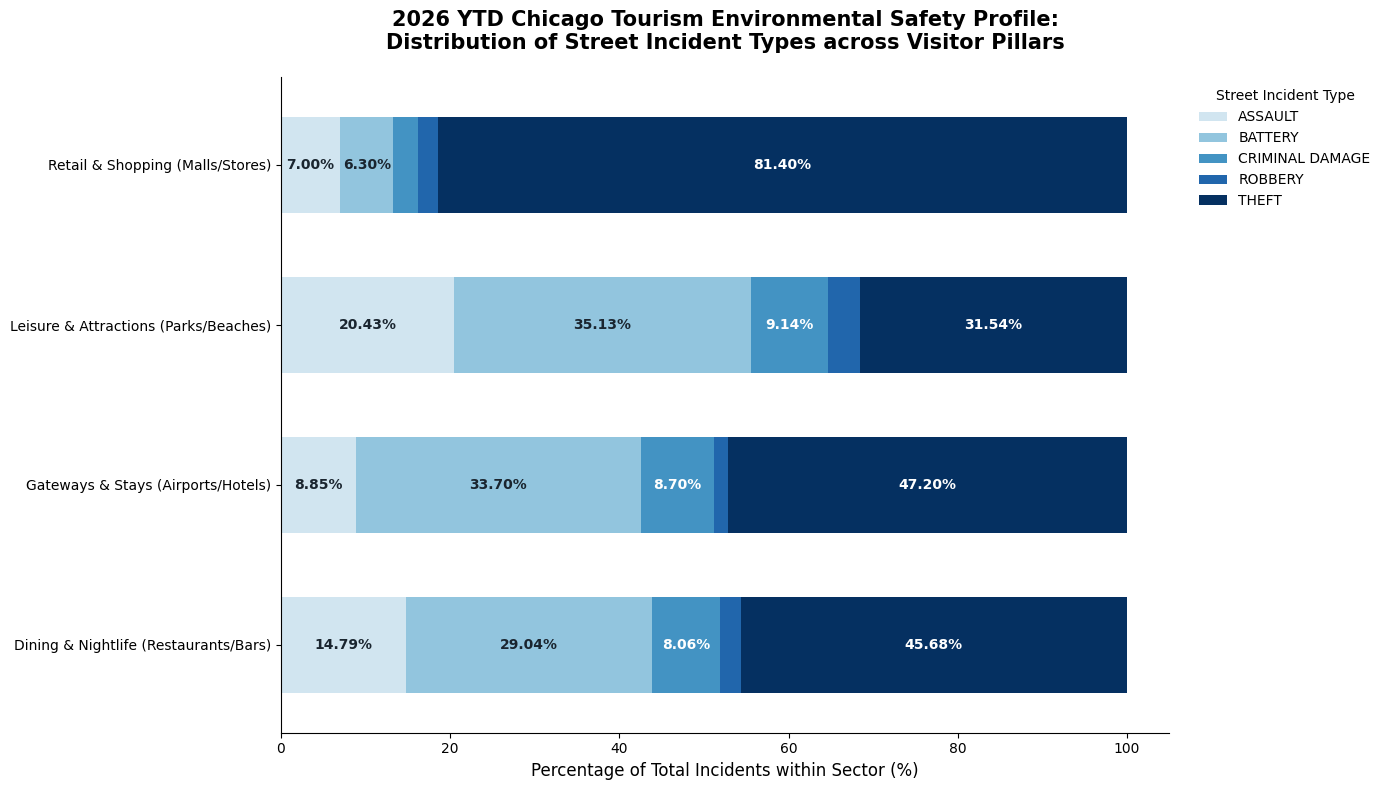

In [40]:
# Custom a continous color scale for better understanding

colors = ["#d1e5f0", "#92c5de", "#4393c3", "#2166ac", "#053061"]


# Axes Setting
ax = pivot_pct.plot(
    kind="barh", 
    stacked=True, 
    figsize=(14, 8), 
    color=colors,
    width=0.6
)

# Adding text labels directly inside the colored segments
for patch in ax.patches:
    width = patch.get_width()
    if width > 5: # Only label segments larger than 5% so text doesn't crowd
        x = patch.get_x() + width / 2
        y = patch.get_y() + patch.get_height() / 2
        ax.text(
            x, y, f"{width:.2f}%", 
            va="center", ha="center", 
            fontsize=10, weight="bold", color="white" if patch.get_facecolor()[0] < 0.5 else "#1a252f"
        )

# Clean up layout styling
plt.title("2026 YTD Chicago Tourism Environmental Safety Profile:\nDistribution of Street Incident Types across Visitor Pillars", fontsize=15, pad=20, weight="bold")
plt.xlabel("Percentage of Total Incidents within Sector (%)", fontsize=12)
plt.ylabel("")
plt.legend(title="Street Incident Type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

#### Arrest Rates for Street Crimes

In [41]:
arrest_data = tourist_df.groupby("primary_type")["arrest"].agg(["sum","size"]).reset_index()

arrest_data = arrest_data.rename(columns = {"sum":"arrest_cnt", "size":"total_case_cnt"})

arrest_data["arrest_rate"] = arrest_data["arrest_cnt"] / arrest_data["total_case_cnt"]

arrest_data["not_arrest_rate"] = 1 - arrest_data["arrest_rate"]

arrest_data

,primary_type,arrest_cnt,total_case_cnt,arrest_rate,not_arrest_rate
0,ASSAULT,179,1068,0.167603,0.832397
1,BATTERY,328,1622,0.202219,0.797781
2,CRIMINAL DAMAGE,57,526,0.108365,0.891635
3,ROBBERY,39,273,0.142857,0.857143
4,THEFT,1790,7683,0.232982,0.767018


In [42]:
arrest_rate = arrest_data[["primary_type", "arrest_rate", "not_arrest_rate"]].sort_values(by="arrest_rate", ascending=False)

arrest_rate

,primary_type,arrest_rate,not_arrest_rate
4,THEFT,0.232982,0.767018
1,BATTERY,0.202219,0.797781
0,ASSAULT,0.167603,0.832397
3,ROBBERY,0.142857,0.857143
2,CRIMINAL DAMAGE,0.108365,0.891635


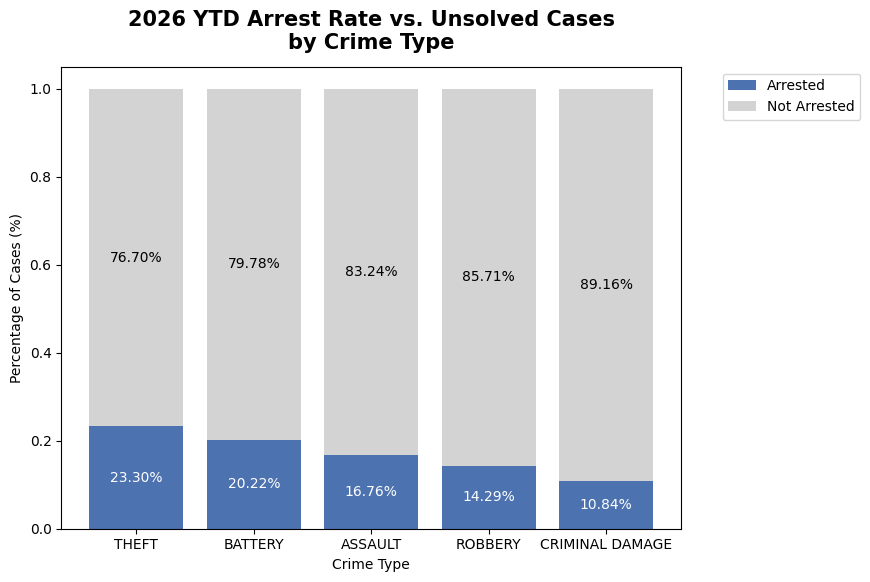

In [43]:
# Setting Fig
plt.figure(figsize=(8,6))

# Create stacked bar chart
plt.bar(arrest_rate["primary_type"], arrest_rate["arrest_rate"], color="#4C72B0", label="Arrested")
plt.bar(arrest_rate["primary_type"], arrest_rate["not_arrest_rate"], bottom=arrest_rate["arrest_rate"], color="#D3D3D3", label="Not Arrested")

# Labels for Arrested Rate
for i, ar in enumerate(arrest_rate["arrest_rate"]):
    plt.text(
        x=i,                      
        y=ar / 2,                 
        s=f"{ar*100:.2f}%",       
        ha="center",
        va="center",
        color="white",
        fontsize=10,
    )

# Labels for Not Arrested Rate
for i, (ar, nar) in enumerate(zip(arrest_rate["arrest_rate"],arrest_rate["not_arrest_rate"])):
    plt.text(
        x=i,                      
        y=ar + nar / 2,           
        s=f"{nar*100:.2f}%",
        ha="center",
        va="center",
        color="black",
        fontsize=10
    )

# Alternative Setting
plt.title("2026 YTD Arrest Rate vs. Unsolved Cases\nby Crime Type", fontsize=15, weight="bold", y=1.02)
plt.xlabel("Crime Type")
plt.ylabel("Percentage of Cases (%)")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.show()

#### Weekly and Hourly Crime Patterns

In [44]:
# Group data and count incidents
heatmap_data = tourist_df.groupby(["weekday", "hour"]).size().reset_index(name="count").pivot(index="weekday", columns="hour", values="count")

# Set weekday order for clean y-axis labelling
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# reindex the pivoted heatmap_data into correct weekday order
heatmap_data = heatmap_data.reindex(weekday_order).iloc[:, 1:] # remove Hour 0 to prevent misleading insights

# To observe Crime Count in a week
day_trend = heatmap_data.sum(axis=1).reset_index(name="cnt")

day_trend["short_days"] = [day[:3] for day in day_trend["weekday"]] # extract first 3 character from weekday column: e.g. Monday to Mon


In [45]:
heatmap_data

hour,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
Monday,25,18,21,16,8,19,29,47,72,57,...,82,123,104,107,92,100,67,46,30,14
Tuesday,21,6,14,13,6,14,31,59,49,69,...,103,124,121,124,100,97,67,52,31,22
Wednesday,12,15,15,10,14,19,25,55,52,82,...,91,101,133,96,113,85,86,59,31,28
Thursday,24,18,16,7,10,14,41,55,57,85,...,138,113,127,115,125,103,77,45,44,31
Friday,19,25,27,17,16,17,30,46,58,74,...,115,123,135,139,132,95,95,56,41,40
Saturday,58,41,35,17,15,12,35,62,77,79,...,112,124,152,144,149,108,92,55,52,63
Sunday,78,83,52,31,18,24,29,59,52,76,...,107,106,123,123,104,95,71,76,46,34


In [46]:
day_trend.head(1)

,weekday,cnt,short_days
0,Monday,1376,Mon


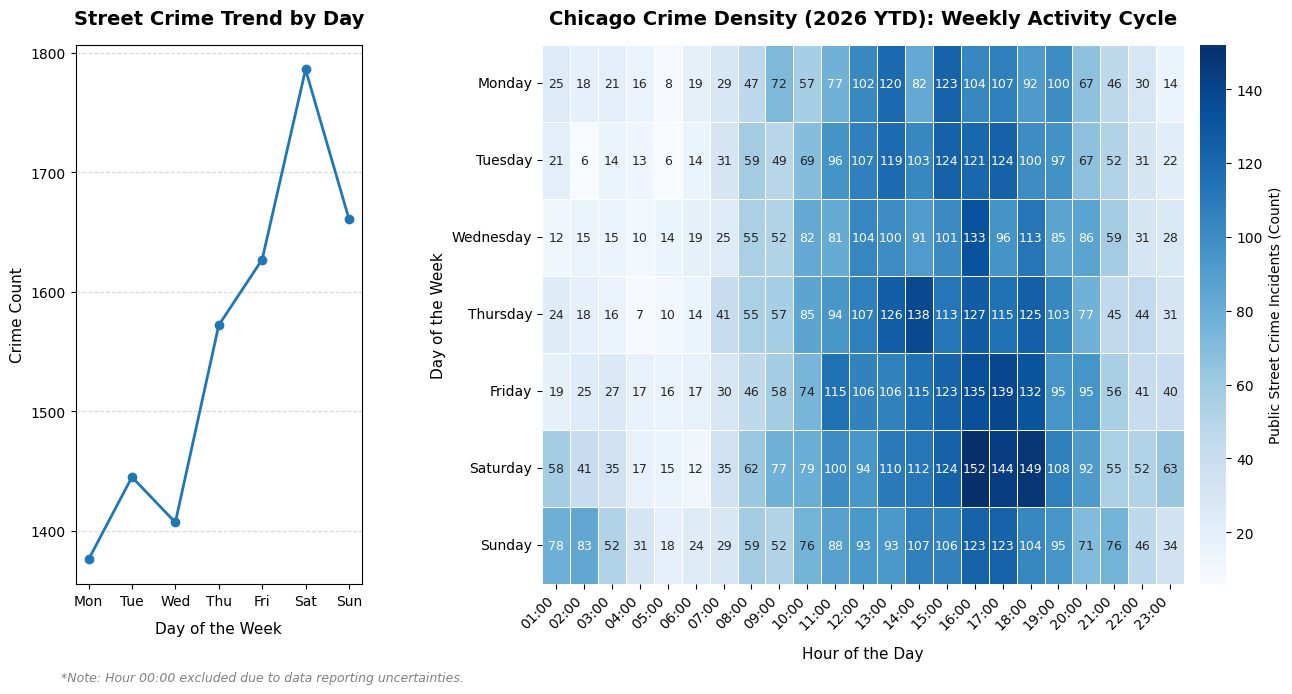

In [47]:
# Fig Setting
fig, ax = plt.subplots(1, 2, figsize=(16, 7), width_ratios=[1, 2.7])

# Column 0 Setting: Line Chart
ax[0].plot(day_trend["short_days"], day_trend["cnt"], marker="o", linewidth=2, color="#1f77b4")
ax[0].set_title("Street Crime Trend by Day", fontsize=14, weight="bold", pad=15)
ax[0].set_xlabel("Day of the Week", fontsize=11, labelpad=10)
ax[0].set_ylabel("Crime Count", fontsize=11)
ax[0].grid(axis="y", linestyle="--", alpha=0.5)


# Column 1 Setting: Heatmap
sns.heatmap(heatmap_data, cmap="Blues", annot=True, fmt="d", linewidths=0.5, 
            linecolor="white", cbar_kws={"label": "Public Street Crime Incidents (Count)", "pad": 0.02}, 
            annot_kws={"fontsize": 9}, ax=ax[1])

ax[1].set_title("Chicago Crime Density (2026 YTD): Weekly Activity Cycle", fontsize=14, weight="bold", pad=15)
ax[1].set_xlabel("Hour of the Day", fontsize=11, labelpad=10)
ax[1].set_ylabel("Day of the Week", fontsize=11)

# SAFE LABEL FORMATTING: Map directly from the dataframe columns instead of UI text
hour_labels = [f"{int(col):02d}:00" for col in heatmap_data.columns]
ax[1].set_xticklabels(hour_labels, rotation=45, ha='right') 
ax[1].set_yticklabels(heatmap_data.index, rotation=0)

# Footnote placement fix (using ax[1].transAxes coordinates carefully)
ax[1].text(-0.75, -0.18, "*Note: Hour 00:00 excluded due to data reporting uncertainties.", 
           transform=ax[1].transAxes, fontsize=9, style="italic", color="gray")

# Remove tight_layout conflict with width_ratios / gridspec
plt.subplots_adjust(wspace=0.34)
plt.show()


#### Weekly and Hourly Crime Patterns (Con't): Hour 0 Logging Issues

<b>Abnormal observation</b> is found in Hour 0 data, as it has the highest crime volume across Monday to Sunday.<br>
This project will try to compare even distribution for each crime in each hour vs. crime volume in hour 0 for specific type of crime.

In [48]:
# Prove the above statements (Hour 0 data is misleading)

# Create a new column to seperate into 2 categories: Midnight (Hour 0) and Other Hour (Hour except 0)
df_2026["Is_Midnight"] = np.where(df_2026["hour"] == 0, "Midnight", "Other Hours")

# Group by Crime Type and whether it was midnight
bias_df = df_2026.groupby(["primary_type", "Is_Midnight"]).size().unstack(fill_value=0)

# % of each crime's total volume that happens at Midnight
bias_df["Total_Incidents"] = bias_df["Midnight"] + bias_df["Other Hours"]
bias_df["Midnight_Share_ %"] = (bias_df["Midnight"] / bias_df["Total_Incidents"]) * 100

# Filter out rare crimes (less than 100 total incidents) so small numbers don't include a skewed results
bias_df = bias_df[bias_df["Total_Incidents"] > 100]

# Sort by the highest concentration at midnight (Top 10)
top_skewed_crimes = bias_df.sort_values(by="Midnight_Share_ %", ascending=False).head(10).reset_index()

# Unbiased hourly crime by each hour %
total_hours_in_day = 24
expected_hourly_share = 100.0 / total_hours_in_day 

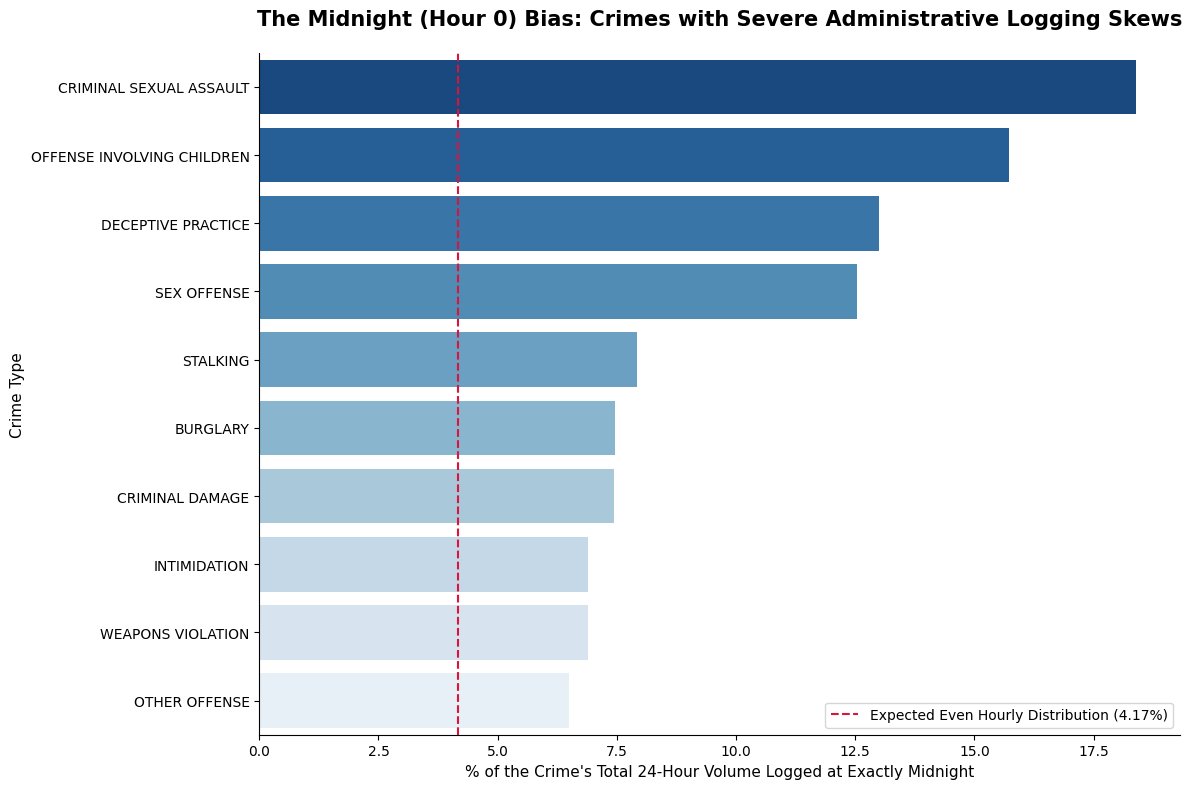

In [49]:
# Visualization
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_skewed_crimes,
    x="Midnight_Share_ %",
    y="primary_type",
    palette="Blues_r",
    hue="primary_type",
    legend=False
)

# Draw a red baseline showing what a "normal, unbiased hour" should look like (4.17%)
plt.axvline(x=expected_hourly_share, color="crimson", linestyle="--", linewidth=1.5, label=f"Expected Even Hourly Distribution ({expected_hourly_share:.2f}%)")

# Text and titles
plt.title("The Midnight (Hour 0) Bias: Crimes with Severe Administrative Logging Skews", fontsize=15, pad=20, weight="bold")
plt.xlabel("% of the Crime\'s Total 24-Hour Volume Logged at Exactly Midnight", fontsize=11)
plt.ylabel("Crime Type", fontsize=11)
plt.legend(loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

The above visualization has shown in all top 10 crimes, they have higher distribution than the unbiased hourly distribution rate,<br>
especially for criminal sexual assault, offense involving children, deceptive practice, and sex offense,<br>
they have at least <b>3 times</b> of the unbiased hourly distribution, it has proven that Hour 0 is containing<br>
logging issue as the Chicago Data Portal mentioned, that refers to for crimes cases that don't have<br>
exact time details, the officer will type the datetime as Hour 0, and this is the reasons why I didn't<br>
include Hour 0 data for the above heatmap.